# Stage 6. Evaluation and Ablation

Notebook ini menguji model pemenang Stage 5 (Full Fusion ResNet18-CSA, tuned) secara klinis mendalam, membuktikan kontribusi tiap komponen arsitektur lewat ablation, mengukur generalisasi lintas populasi, dan menjadi dasar checklist pelaporan STARD dan TRIPOD.

## Environment Setup

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent.parent))

import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import roc_curve, auc, confusion_matrix, cohen_kappa_score, f1_score

from configs import paths
from src.common import eval as evaluation
from src.common import features, manifest as manifest_utils, train
from src.sites.conjunctiva import data

output_dir = paths.outputs_dir("conjunctiva")
print("device", "cuda" if torch.cuda.is_available() else "cpu")

device cuda


# Part A. Deep Clinical Evaluation

Bagian ini memakai prediksi out-of-fold model tuned dari Stage 5, tanpa pelatihan ulang.

In [2]:
manifest = manifest_utils.assign_kfold(data.build_manifest(save=False), n_splits=5, seed=42)
handcrafted = pd.read_csv(output_dir / "handcrafted_features.csv")
embeddings_resnet18 = np.load(output_dir / "deep_embeddings.npy")
embedding_uids_resnet18 = pd.read_csv(output_dir / "deep_embeddings_uids.csv")["uid"].tolist()

oof = pd.read_csv(output_dir / "multitask_oof_full_fusion_resnet18_csa_tuned.csv")
with open(output_dir / "multitask_optuna_best_params.json") as handle:
    best_params = json.load(handle)["best_params"]

print("oof rows", len(oof))
print("best params", best_params)

Eyes-Defy Italy melewati 2 folder tanpa metadata atau file lengkap: [93, 95]


Eyes-Defy India melewati 1 folder tanpa metadata atau file lengkap: [7]
oof rows 925
best params {'learning_rate': 0.003055737416493421, 'epochs': 84, 'weight_classification': 1.9482952299704612, 'weight_severity': 0.3896833153575715, 'focal_gamma': 2.0367179391695727, 'dropout': 0.3119141432082831, 'trunk_dim': 256, 'attention_dim': 32, 'batch_size': 64}


## Recompute Classification Probabilities

Prediksi out-of-fold Stage 5 hanya menyimpan kelas hasil argmax, bukan probabilitas kontinu yang dibutuhkan untuk analisis ROC dan threshold Youden yang bermakna. Probabilitas dihitung ulang lewat inferensi memakai checkpoint per fold yang sudah tersimpan, tanpa melatih ulang model, sehingga hasilnya identik dengan model yang sudah dilatih.

In [3]:
artifact_dir = paths.artifacts_dir("conjunctiva")
checkpoint_paths = [artifact_dir / f"multitask_full_fusion_resnet18_tuned_fold{i}.pt" for i in range(5)]

probabilities = train.recompute_oof_probabilities(
    manifest, handcrafted, embeddings_resnet18, embedding_uids_resnet18, checkpoint_paths,
    trunk_dim=best_params["trunk_dim"], attention_dim=best_params["attention_dim"], dropout=best_params["dropout"],
)
oof = oof.merge(probabilities[["uid", "anemic_prob"]], on="uid", how="left")

consistency_check = (oof["anemic_prob"] >= 0.5).astype(int)
print("konsistensi dengan anemic_pred tersimpan:", round((consistency_check == oof["anemic_pred"]).mean(), 4))

konsistensi dengan anemic_pred tersimpan: 1.0


## Bland-Altman Analysis for Hemoglobin Regression

Bias mendekati nol dan limits of agreement yang sempit menandakan prediksi Hb tidak bias secara sistematis terhadap nilai laboratorium.

MAE 1.554
RMSE 2.0419
R squared 0.3351
bias 0.0886
limits of agreement -3.9119 to 4.089


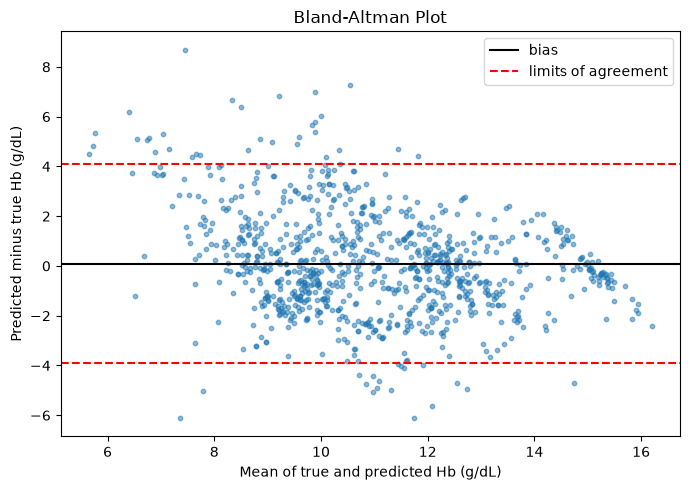

In [4]:
regression_metrics = evaluation.regression_summary(oof["hb_true"], oof["hb_pred"])
bland_altman = evaluation.bland_altman_stats(oof["hb_true"], oof["hb_pred"])
print("MAE", round(regression_metrics["mae"], 4))
print("RMSE", round(regression_metrics["rmse"], 4))
print("R squared", round(regression_metrics["r_squared"], 4))
print("bias", round(bland_altman["bias"], 4))
print("limits of agreement", round(bland_altman["lower_limit"], 4), "to", round(bland_altman["upper_limit"], 4))

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(bland_altman["mean_value"], bland_altman["difference"], s=10, alpha=0.5)
ax.axhline(bland_altman["bias"], color="black", label="bias")
ax.axhline(bland_altman["lower_limit"], color="red", linestyle="--", label="limits of agreement")
ax.axhline(bland_altman["upper_limit"], color="red", linestyle="--")
ax.set_xlabel("Mean of true and predicted Hb (g/dL)")
ax.set_ylabel("Predicted minus true Hb (g/dL)")
ax.set_title("Bland-Altman Plot")
ax.legend()
plt.tight_layout()
plt.show()

## ROC Curve and Sensitivity-Prioritized Threshold

Skrining anemia mengutamakan sensitivitas agar kasus positif tidak terlewat. Threshold Youden dicari sebagai alternatif dari threshold default 0.5 yang dipakai pada Stage 5.

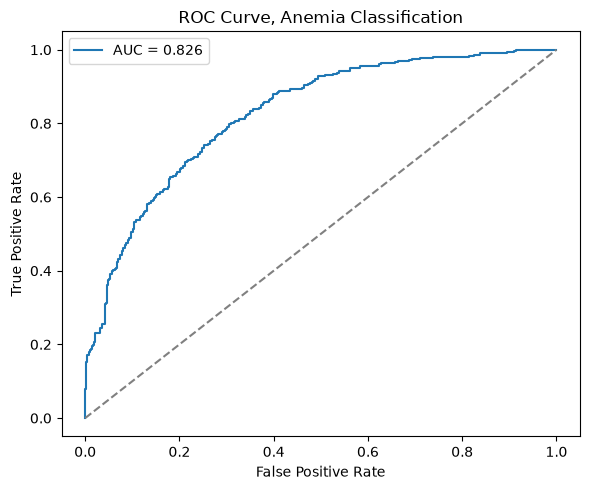

AUC 0.8261
Youden threshold 0.428
Youden sensitivity 0.7977 specificity 0.6959


In [5]:
y_true = oof["anemic_true"].to_numpy()
y_prob = oof["anemic_prob"].to_numpy().astype(np.float64)

false_positive_rate, true_positive_rate, _ = roc_curve(y_true, y_prob)
roc_auc = auc(false_positive_rate, true_positive_rate)
youden = evaluation.youden_optimal_threshold(y_true, y_prob)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(false_positive_rate, true_positive_rate, label=f"AUC = {roc_auc:.3f}")
ax.plot([0, 1], [0, 1], linestyle="--", color="grey")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve, Anemia Classification")
ax.legend()
plt.tight_layout()
plt.show()

print("AUC", round(roc_auc, 4))
print("Youden threshold", round(youden["threshold"], 4))
print("Youden sensitivity", round(youden["sensitivity"], 4), "specificity", round(youden["specificity"], 4))

In [6]:
for label, threshold in [("default 0.5", 0.5), ("Youden", youden["threshold"])]:
    prediction = (y_prob >= threshold).astype(int)
    ppv_npv = evaluation.ppv_npv(y_true, prediction)
    f1 = f1_score(y_true, prediction)
    tn, fp, fn, tp = confusion_matrix(y_true, prediction).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) else float("nan")
    specificity = tn / (tn + fp) if (tn + fp) else float("nan")
    print(label)
    print("  sensitivity", round(sensitivity, 4), "specificity", round(specificity, 4))
    print("  PPV", round(ppv_npv["ppv"], 4), "NPV", round(ppv_npv["npv"], 4), "F1", round(f1, 4))

default 0.5
  sensitivity 0.7101 specificity 0.7616
  PPV 0.7883 NPV 0.6775 F1 0.7472
Youden
  sensitivity 0.7977 specificity 0.6959
  PPV 0.7664 NPV 0.7333 F1 0.7817


## Severity Confusion Matrix and Cohen's Kappa

Cohen's kappa mengukur kesesuaian klasifikasi severity empat kelas terhadap label sebenarnya, terkoreksi dari kesesuaian yang mungkin terjadi secara kebetulan.

In [7]:
severity_valid = oof["severity_true"] >= 0
severity_true = oof.loc[severity_valid, "severity_true"]
severity_pred = oof.loc[severity_valid, "severity_pred"]

kappa = cohen_kappa_score(severity_true, severity_pred)
print("Cohen kappa (severity)", round(kappa, 4))
print("confusion matrix (baris label sebenarnya, kolom prediksi):")
print(confusion_matrix(severity_true, severity_pred))

Cohen kappa (severity) 0.1471
confusion matrix (baris label sebenarnya, kolom prediksi):
[[125  93  68   0]
 [ 19  18 101   6]
 [ 39  36 151   6]
 [  6  11  30   1]]


# Part B. Component Ablation

Setiap komponen dimatikan satu per satu dari konfigurasi Full Fusion ResNet18-CSA tuned, memakai hyperparameter terbaik Stage 5 sebagai basis, agar perbandingan adil.

In [8]:
backbone_no_csa = features.EmbeddingBackbone(backbone_name="resnet18", use_csa=False)
embeddings_no_csa, embedding_uids_no_csa = features.extract_deep_embeddings(manifest, model=backbone_no_csa)
print("embeddings without CSA", embeddings_no_csa.shape)

embeddings without CSA (925, 256)


In [9]:
def run_full_fusion(embeddings=None, embedding_uids=None, **overrides):
    embeddings = embeddings_resnet18 if embeddings is None else embeddings
    embedding_uids = embedding_uids_resnet18 if embedding_uids is None else embedding_uids
    kwargs = dict(
        epochs=best_params["epochs"], batch_size=best_params["batch_size"], learning_rate=best_params["learning_rate"],
        loss_weights=(1.0, best_params["weight_classification"], best_params["weight_severity"]),
        trunk_dim=best_params["trunk_dim"], attention_dim=best_params["attention_dim"],
        dropout=best_params["dropout"], focal_gamma=best_params["focal_gamma"],
        use_handcrafted=True, use_deep=True,
    )
    kwargs.update(overrides)
    return train.run_kfold(manifest, handcrafted, embeddings, embedding_uids, n_splits=5, **kwargs)


ablation_results = {}
ablation_results["CSA off"] = run_full_fusion(embeddings=embeddings_no_csa, embedding_uids=embedding_uids_no_csa)
ablation_results["Fusion Attention off"] = run_full_fusion(use_fusion_attention=False)
ablation_results["Dual Loss off (MSE only)"] = run_full_fusion(regression_loss="mse_only")
ablation_results["Site token off"] = run_full_fusion(use_site_token=False)
ablation_results["Demographics off"] = run_full_fusion(use_demographics=False)

print("selesai lima run ablation")

selesai lima run ablation


In [10]:
baseline_fold_metrics = pd.read_csv(output_dir / "multitask_fold_metrics_full_fusion_resnet18_csa_tuned.csv")
ablation_rows = [{
    "configuration": "Full Fusion ResNet18-CSA (tuned, baseline)",
    "mae_mean": baseline_fold_metrics["mae"].mean(),
    "accuracy_mean": baseline_fold_metrics["accuracy"].mean(),
}]
for name, result in ablation_results.items():
    metrics = result["fold_metrics"]
    ablation_rows.append({
        "configuration": name,
        "mae_mean": metrics["mae"].mean(),
        "accuracy_mean": metrics["accuracy"].mean(),
    })
ablation_table = pd.DataFrame(ablation_rows)
print(ablation_table.round(4).to_string(index=False))
ablation_table.to_csv(output_dir / "ablation_component_comparison.csv", index=False)

                             configuration  mae_mean  accuracy_mean
Full Fusion ResNet18-CSA (tuned, baseline)    1.5538         0.7329
                                   CSA off    1.6156         0.7589
                      Fusion Attention off    1.5375         0.7665
                  Dual Loss off (MSE only)    1.5802         0.7374
                            Site token off    1.6186         0.7178
                          Demographics off    1.6184         0.7319


# Part C. Cross-Dataset Generalization

Model dilatih pada satu populasi dan diuji pada populasi lain yang sama sekali tidak terlihat saat pelatihan. Site token menjadi konstan pada skenario ini karena data latih hanya berasal dari satu populasi, sehingga tidak benar-benar berperan sebagai sinyal adaptasi. Hasil dibandingkan dengan temuan Paper 1 yang melaporkan balanced accuracy sekitar 0.56 tanpa maupun dengan adaptasi CORAL.

In [11]:
cp_manifest = manifest[manifest["dataset"] == "cp_anemic"].reset_index(drop=True)
eyes_manifest = manifest[manifest["dataset"] == "eyes_defy"].reset_index(drop=True)

cross_kwargs = dict(
    epochs=best_params["epochs"], batch_size=best_params["batch_size"], learning_rate=best_params["learning_rate"],
    loss_weights=(1.0, best_params["weight_classification"], best_params["weight_severity"]),
    trunk_dim=best_params["trunk_dim"], attention_dim=best_params["attention_dim"],
    dropout=best_params["dropout"], focal_gamma=best_params["focal_gamma"],
)

cp_to_eyes = train.run_cross_dataset(
    cp_manifest, eyes_manifest, handcrafted, embeddings_resnet18, embedding_uids_resnet18, **cross_kwargs
)
eyes_to_cp = train.run_cross_dataset(
    eyes_manifest, cp_manifest, handcrafted, embeddings_resnet18, embedding_uids_resnet18, **cross_kwargs
)

generalization_table = pd.DataFrame([
    {"direction": "CP-AnemiC to Eyes-Defy", **{k: v for k, v in cp_to_eyes.items() if k != "model"}},
    {"direction": "Eyes-Defy to CP-AnemiC", **{k: v for k, v in eyes_to_cp.items() if k != "model"}},
])
print(generalization_table.round(4).to_string(index=False))
print("pembanding Paper 1 (balanced accuracy tanpa adaptasi maupun dengan CORAL): sekitar 0.56")
generalization_table.to_csv(output_dir / "cross_dataset_generalization.csv", index=False)

             direction    mae  accuracy  sensitivity  specificity  balanced_accuracy
CP-AnemiC to Eyes-Defy 2.4169    0.4884       0.0778       0.7840             0.4309
Eyes-Defy to CP-AnemiC 2.8526    0.5127       0.6722       0.2762             0.4742
pembanding Paper 1 (balanced accuracy tanpa adaptasi maupun dengan CORAL): sekitar 0.56
